Masons Dataset
Dataset that has the condemned and dead-end properties.
https://data.wprdc.org/dataset/condemned-properties/resource/0a963f26-eb4b-4325-bbbc-3ddf6a871410

neighborhood
Duquesne Heights              1
Strip District                1
Friendship                    1
Allegheny West                1
Central Oakland               1
                           ... 
Knoxville                   180
Lincoln-Lemington-Belmar    183
Homewood North              183
Perry South                 185
Hazelwood                   201
Name: count, Length: 85, dtype: int64
neighborhood
Duquesne Heights             1
Strip District               1
Friendship                   1
Allegheny West               1
Central Oakland              1
Chateau                      1
Central Business District    1
South Shore                  1
Banksville                   2
Swisshelm Park               2
North Oakland                2
Arlington Heights            2
Summer Hill                  3
Glen Hazel                   3
Point Breeze                 4
Name: count, dtype: int64


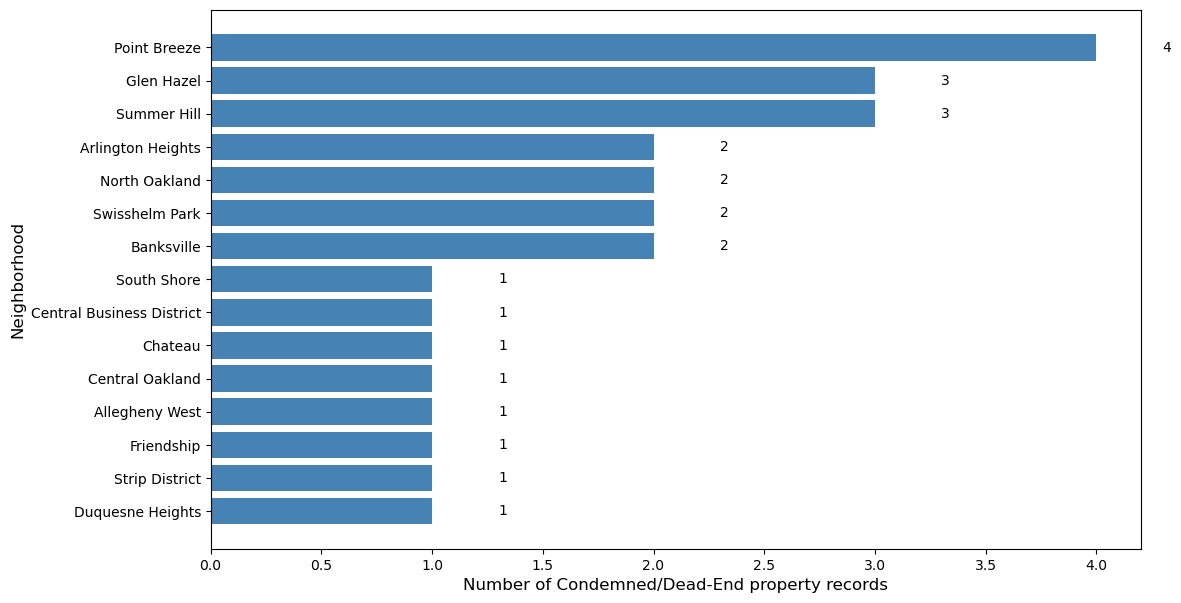

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('condemnedanddead-endproperties.csv')
df.head()

#This counts how many rows, property records, each neighborhood has
#Then sorts from lowest to highest because fewest condemned houses is the best neighborhood
neighborhood_counts = df['neighborhood'].value_counts().sort_values(ascending=True)
print(neighborhood_counts)

#This takes the first 15 neighborhoods from the sorted list
best_neighborhoods = neighborhood_counts.head(15)
print(best_neighborhoods)

plt.figure(figsize=(12,7))
plt.barh(best_neighborhoods.index, best_neighborhoods.values, color = 'steelblue')
plt.xlabel('Number of Condemned/Dead-End property records', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)

for i, value in enumerate(best_neighborhoods.values):
    plt.text(value + 0.3, i, str(value), va='center', fontsize = 10)

plt.show()

In [20]:
#Get the 8 tied neighborhoods
tied = neighborhood_counts[neighborhood_counts == 1].index

#Filter the original dataframe to only the top 8
tied_df = df[df['neighborhood'].isin(tied)]

#Show inspection results for each
print(tied_df[['neighborhood', 'latest_inspection_result']])

                   neighborhood latest_inspection_result
507                 South Shore                     Fail
529                     Chateau                     Fail
643   Central Business District                     Fail
1113           Duquesne Heights                     Pass
1160             Strip District                     Fail
2589                 Friendship                     Fail
2834             Allegheny West                     Fail
3188            Central Oakland                     Pass


In [21]:
#Show score for each tied neighborhood
print(tied_df[['neighborhood', 'latest_inspection_score']])

                   neighborhood  latest_inspection_score
507                 South Shore                      3.0
529                     Chateau                      1.0
643   Central Business District                      1.0
1113           Duquesne Heights                      0.0
1160             Strip District                      1.0
2589                 Friendship                      1.0
2834             Allegheny West                      2.0
3188            Central Oakland                      0.0


In [22]:
print(tied_df[['neighborhood', 'inspection_status']])

                   neighborhood inspection_status
507                 South Shore            Active
529                     Chateau            Active
643   Central Business District            Active
1113           Duquesne Heights            Active
1160             Strip District            Active
2589                 Friendship            Active
2834             Allegheny West            Active
3188            Central Oakland            Active


In [23]:
summary = tied_df[['neighborhood', 'latest_inspection_result', 'latest_inspection_score', 'inspection_status']]
print(summary.to_string(index=False))

             neighborhood latest_inspection_result  latest_inspection_score inspection_status
              South Shore                     Fail                      3.0            Active
                  Chateau                     Fail                      1.0            Active
Central Business District                     Fail                      1.0            Active
         Duquesne Heights                     Pass                      0.0            Active
           Strip District                     Fail                      1.0            Active
               Friendship                     Fail                      1.0            Active
           Allegheny West                     Fail                      2.0            Active
          Central Oakland                     Pass                      0.0            Active


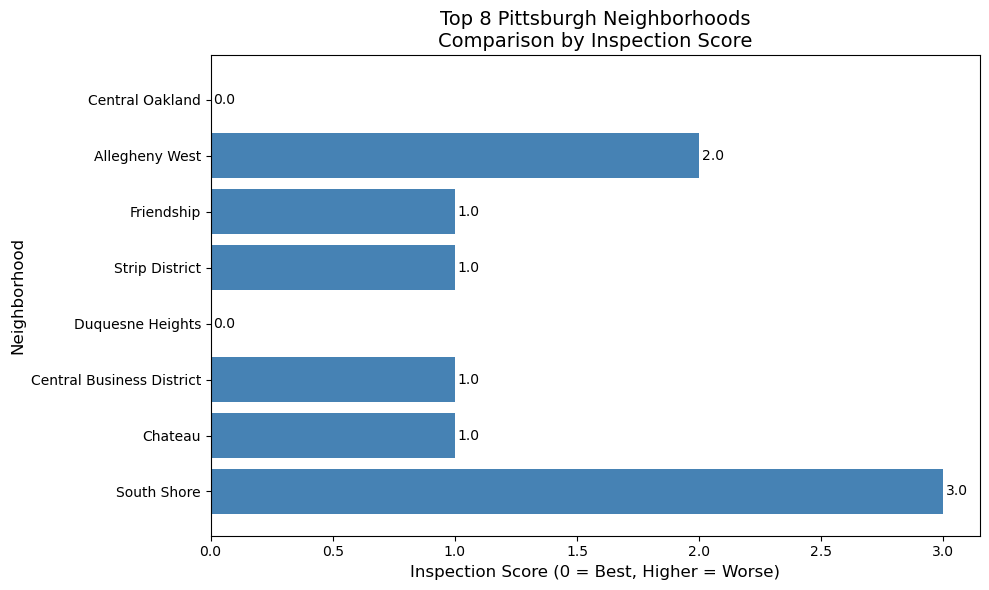

In [25]:
# Set up the graph using inspection score (0 = best, higher = worse)
plt.figure(figsize=(10, 6))

plt.barh(summary['neighborhood'], summary['latest_inspection_score'], color='steelblue')

plt.xlabel('Inspection Score (0 = Best, Higher = Worse)', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)
plt.title('Top 8 Pittsburgh Neighborhoods\nComparison by Inspection Score', fontsize=14)

# Add the score number at the end of each bar
for i, value in enumerate(summary['latest_inspection_score']):
    plt.text(value + 0.01, i, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()